# NETFLIX DATA ANALYSIS

In [2]:
%pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
def load_data(path):
    df = pd.read_csv(path, encoding='latin1' , compression='zip')
    return df

In [26]:
# Data cleaning
def clean_data(df):
    df = df.dropna(subset=['type','release_year','rating','country','duration'])
    return df

In [30]:
def plot_type_distribution(df):
    type_counts = df['type'].value_counts()
    
    plt.figure(figsize=(6,4))
    plt.bar(type_counts.index, type_counts.values, color=['skyblue','orange'])
    plt.title('Distribution of Content Types on Netflix')
    plt.xlabel('Type')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('images/movies_vs_tvshows.png')
    plt.show()

In [31]:
# Rating Pie Chart
def plot_rating_distribution(df):
    rating_counts = df['rating'].value_counts().head(6)
    
    plt.figure(figsize=(8,8))
    plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Percentage of Content Rating')
    plt.tight_layout()
    plt.savefig('images/content_rating_pie.png')
    plt.show()

In [32]:
# Movie Duration
def plot_movie_duration(df):
    movie_df = df[df['type'] == 'Movie'].copy()
    movie_df['duration_int'] = movie_df['duration'].str.replace('min','').astype(int)

    plt.figure(figsize=(8,6))
    plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor='black')
    plt.title('Distribution of Movie Duration')
    plt.xlabel('Duration (minutes)')
    plt.ylabel('Number of Movies')
    plt.tight_layout()
    plt.savefig('images/movie_duration_histogram.png')
    plt.show()

In [35]:
# Release Year Scatter
def plot_release_year(df):
    release_counts = df['release_year'].value_counts().sort_index()

    plt.figure(figsize=(10,6))
    plt.scatter(release_counts.index, release_counts.values, color='red')
    plt.title('Release Year vs Number of Shows')
    plt.xlabel('Release Year')
    plt.ylabel('Number of Shows')
    plt.tight_layout()
    plt.savefig('images/release_year_scatter.png')
    plt.show()

In [36]:
# Top Countries
def plot_top_countries(df):
    country_counts = df['country'].value_counts().head(10)

    plt.figure(figsize=(8,6))
    plt.bar(country_counts.index, country_counts.values, color='teal')
    plt.title('Top 10 Countries by Number of Shows')
    plt.xlabel('Number of Shows')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.savefig('images/top10_countries.png')
    plt.show()

In [37]:
# Movies VS TV Shows Trend
def plot_content_trend(df):
    content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

    fig, ax = plt.subplots(1,2, figsize=(12,5))

    # Movies
    ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
    ax[0].set_title('Movies Released Per Year')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Number of Movies')

    # TV Shows
    ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
    ax[1].set_title('TV Shows Released Per Year')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Number of TV Shows')

    fig.suptitle('Movies vs TV Shows Over Time')
    plt.tight_layout()
    plt.savefig('images/movies_tv_comparison.png')
    plt.show()

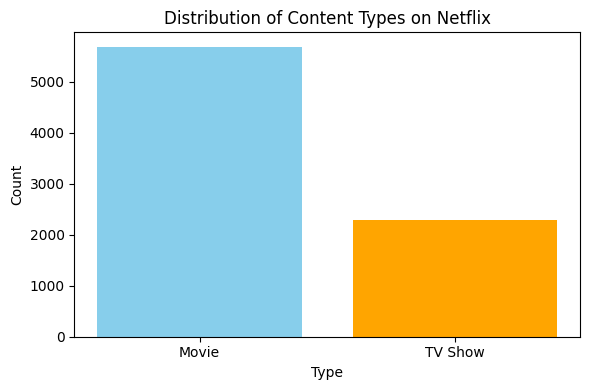

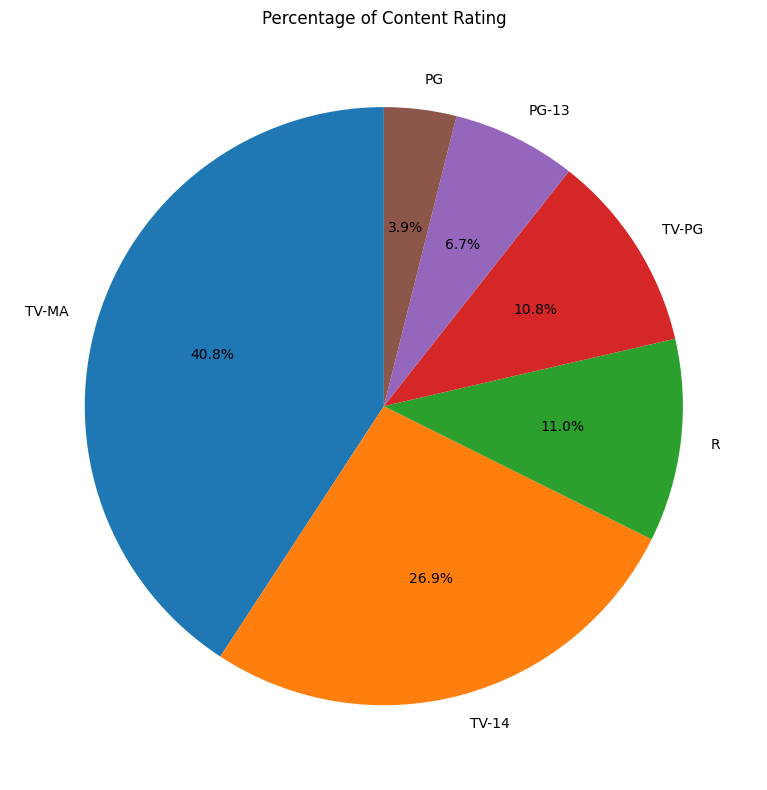

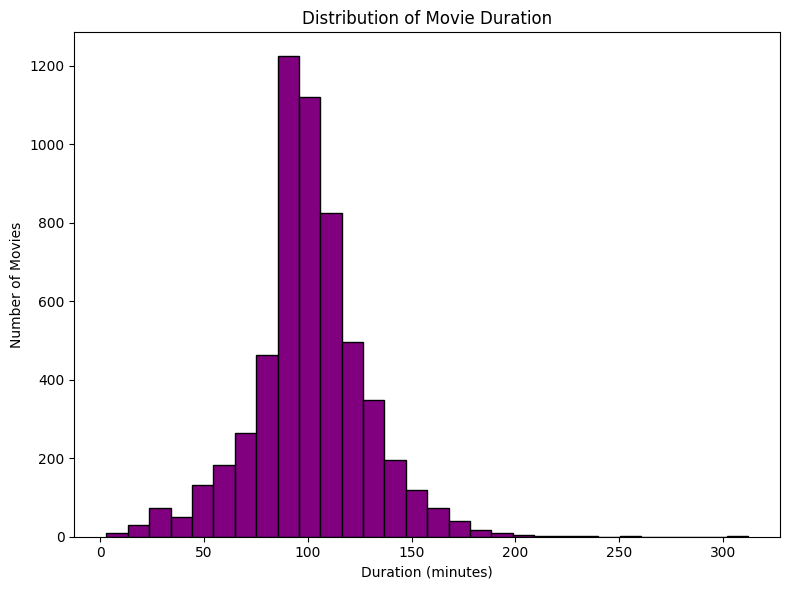

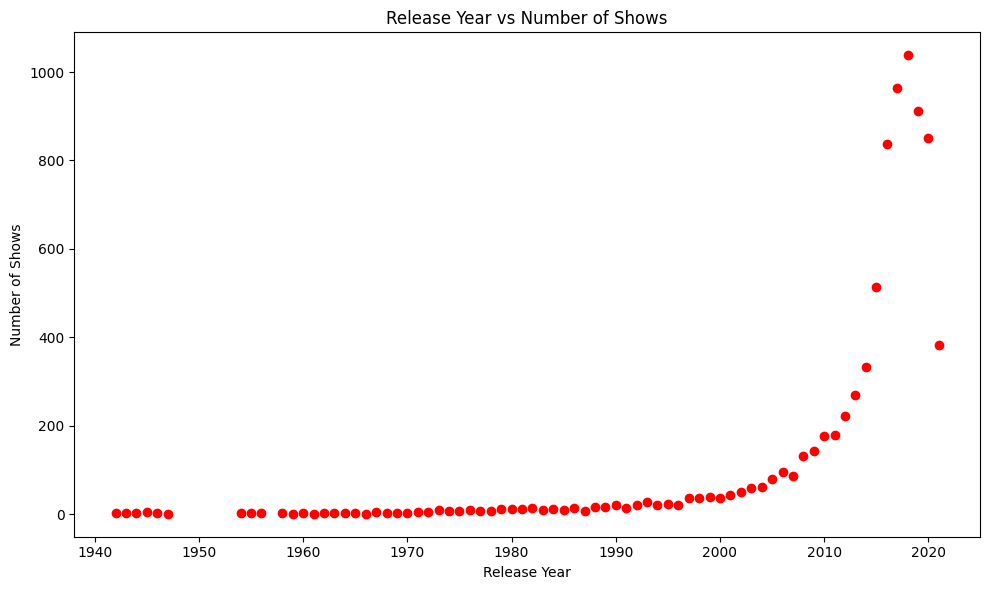

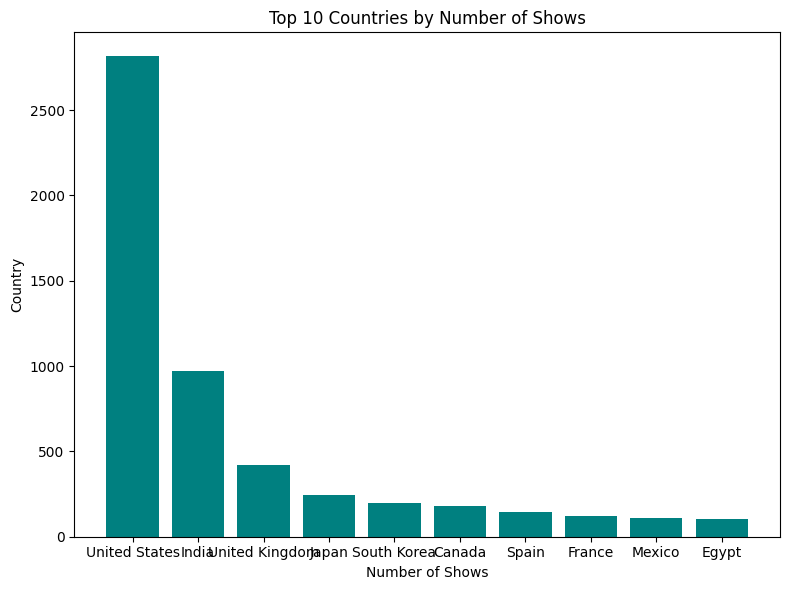

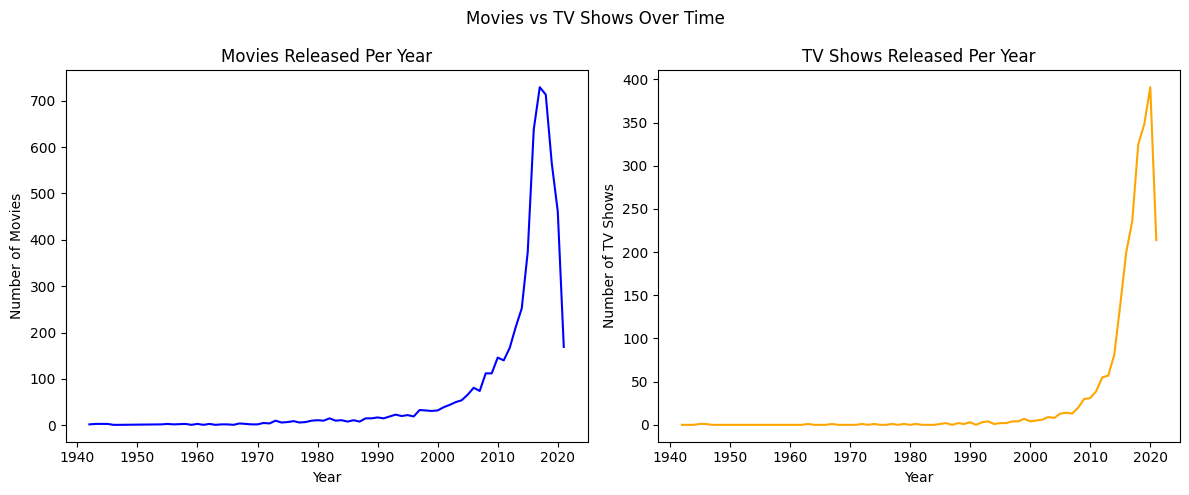

In [39]:
# Main Function
def main():
    df = load_data("data/netflix_titles.csv.zip")
    df = clean_data(df)

    plot_type_distribution(df)
    plot_rating_distribution(df)
    plot_movie_duration(df)
    plot_release_year(df)
    plot_top_countries(df)
    plot_content_trend(df)

if __name__ == "__main__":
    main()

## Key Insights

1. Movies dominate Netflix content, accounting for approximately 70% of total content, while TV Shows make up around 30%.

2. TV-MA and TV-14 are the most common ratings, together contributing over 60% of content, indicating a strong focus on mature audiences.

3. Most movies fall within the 80–120 minute range, with a peak around 90–100 minutes, reflecting a standard runtime pattern.

4. The United States is the leading content producer, contributing the highest number of titles.

5. Content production increased significantly after 2015, highlighting Netflix’s rapid expansion.
